In [1]:
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Input, LeakyReLU,GaussianNoise,Concatenate
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import concatenate, multiply
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.layers import PReLU
from tensorflow.keras.optimizers.legacy import Adam as LegacyAdam
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers.experimental import AdamW
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.regularizers import l2


In [2]:

data=pd.read_excel("data - copie.xlsx")
data = data.replace({',': '.'}, regex=True)
data.columns=['p','v','h','t','Ra','Desnity','VED','LED','PED']


data2=pd.read_excel('synthetic_data_gmm_1400.xlsx')
data2 = data2.replace({',': '.'}, regex=True)

data2.columns=['p','v','h','t','Ra']

In [3]:
X_selected=['p','v','h','t']
X = data[X_selected].values
y = data[['Ra']].values
X2 = data2[X_selected].values
y2 = data2[['Ra']].values

In [4]:
X_combined = np.vstack((X, X2))
y_combined = np.vstack((y, y2))
data_combined = pd.DataFrame(X_combined, columns=X_selected)
data_combined['Ra'] = y_combined

In [5]:

def box_cox_fun(data, lambda_val=0.5):
    return ((data + 1e-5) ** lambda_val - 1) / lambda_val

def inverse_box_cox(data, lambda_val=0.5):
    if lambda_val == 0:
        return np.exp(data)
    else:
        return (data * lambda_val + 1) ** (1 / lambda_val) - 1e-5

In [6]:

X = data_combined[['p', 'v', 'h', 't',]].values
y = data_combined[['Ra']].values

scaler_x = StandardScaler()
X_scaled = scaler_x.fit_transform(X)


In [7]:
latent_dim = 400
condition_dim = 4


from tensorflow.keras.layers import Add

def build_generator(latent_dim=400, condition_dim=4):
    
    noise_input = Input(shape=(latent_dim,))
    condition_input = Input(shape=(condition_dim,))

    
    x = Dense(512)(noise_input)
    x = BatchNormalization()(x)
    x = PReLU()(x)

    x = Dense(256)(x)
    x = BatchNormalization()(x)
    x = PReLU()(x)

    x = Dense(128)(x)
    x = BatchNormalization()(x)
    x = PReLU()(x)

    # === Condition branch (deep) ===
    c = Dense(128)(condition_input)
    c = PReLU()(c)
    c = Dense(64)(c)
    c = PReLU()(c)
    c = Dense(32)(c)
    c = PReLU()(c)

    # === Fusion ===
    merged = Concatenate()([x, c])
    x = Dense(128)(merged)
    x = BatchNormalization()(x)
    x = PReLU()(x)
    
    x = Dense(64)(x)
    x = BatchNormalization()(x)
    x = PReLU()(x)

    
    raw_output = Dense(1)(x)

  
    adjust = Dense(1)(c)
    final_output = Add()([raw_output, adjust])

    output = Activation('linear')(final_output)  

    return Model([noise_input, condition_input], output)


In [8]:

def build_discriminator():
    ra_input = Input(shape=(1,))
    cond_input = Input(shape=(4,))
    x = Concatenate()([ra_input, cond_input])
    x = Dense(128)(x)
    x = LeakyReLU(0.2)(x)
    x = Dense(64)(x)
    x = LeakyReLU(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model([ra_input, cond_input], out)


lr_schedule = ExponentialDecay(0.0001, decay_steps=1000, decay_rate=0.96)
disc_optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4, beta_1=0.5)
gen_optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4, beta_1=0.5)


discriminator = build_discriminator()
discriminator.trainable = True
discriminator.compile(loss='binary_crossentropy', optimizer=disc_optimizer, metrics=['accuracy'])

generator = build_generator()
discriminator.trainable = False


In [9]:
def build_gan(generator, discriminator): 
    discriminator.trainable = False 
    noise = Input(shape=(latent_dim,))
    condition = Input(shape=(condition_dim,))
    generated_ra = generator([noise, condition])
    validity = discriminator([generated_ra, condition])
    return Model([noise, condition], validity)


gan = build_gan(generator, discriminator)


In [10]:
mse_loss = MeanSquaredError()
lambda_mse = 10
lambda_reg = 1e-4

# ===== Training =====
def train_gan(gan, generator, discriminator, X, y, n_epochs=10000, batch_size=64, log_every=100):
    half_batch = batch_size // 2

    for epoch in range(n_epochs):
        # === Discriminator ===
        idx = np.random.randint(0, X.shape[0], half_batch)
        real_conditions = X[idx]
        real_Ra = y[idx]
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_Ra = generator.predict([noise, real_conditions], verbose=0)

        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        discriminator.trainable = True
        d_loss_real, acc_real = discriminator.train_on_batch([real_Ra, real_conditions], real_labels)
        d_loss_fake, acc_fake = discriminator.train_on_batch([fake_Ra, real_conditions], fake_labels)

        # === Generator ===
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        cond_idx = np.random.randint(0, X.shape[0], batch_size)
        conditions = X[cond_idx]
        real_target = y[cond_idx].reshape(-1, 1)
        valid_labels = np.ones((batch_size, 1))

        discriminator.trainable = False
        with tf.GradientTape() as tape:
            generated_ra = generator([noise, conditions], training=True)
            validity = discriminator([generated_ra, conditions], training=False)
            gan_loss = tf.keras.losses.binary_crossentropy(valid_labels, validity)
            mse = mse_loss(real_target, generated_ra)
            reg_loss = tf.reduce_sum(generator.losses)
            total_loss = gan_loss + lambda_mse * mse + lambda_reg * reg_loss

        grads = tape.gradient(total_loss, generator.trainable_weights)
        gen_optimizer.apply_gradients(zip(grads, generator.trainable_weights))

        # === Logs ===
        if (epoch + 1) % log_every == 0:
            print(f"Mean Ra réel: {real_target.mean():.4f} | généré: {generated_ra.numpy().mean():.4f}")
            print(f"Epoch {epoch + 1} | D real: {d_loss_real:.3f} ({acc_real*100:.2f}%) | "
                  f"D fake: {d_loss_fake:.3f} ({acc_fake*100:.2f}%) | G(MSE): {mse.numpy():.3f}")

In [11]:
train_gan(gan, generator, discriminator, X_scaled, y)

Mean Ra réel: 10.6128 | généré: 1.9469
Epoch 100 | D real: 0.082 (100.00%) | D fake: 0.668 (56.25%) | G(MSE): 102.763
Mean Ra réel: 10.5690 | généré: 4.7076
Epoch 200 | D real: 0.328 (100.00%) | D fake: 0.738 (28.12%) | G(MSE): 58.802
Mean Ra réel: 10.2668 | généré: 7.2694
Epoch 300 | D real: 0.736 (53.12%) | D fake: 0.665 (65.62%) | G(MSE): 24.727
Mean Ra réel: 10.2697 | généré: 9.6372
Epoch 400 | D real: 0.672 (56.25%) | D fake: 0.673 (62.50%) | G(MSE): 21.115
Mean Ra réel: 10.4338 | généré: 10.3718
Epoch 500 | D real: 0.728 (37.50%) | D fake: 0.654 (75.00%) | G(MSE): 15.752
Mean Ra réel: 10.0709 | généré: 10.1317
Epoch 600 | D real: 0.736 (56.25%) | D fake: 0.673 (65.62%) | G(MSE): 14.822
Mean Ra réel: 10.3985 | généré: 10.0813
Epoch 700 | D real: 0.743 (34.38%) | D fake: 0.675 (68.75%) | G(MSE): 19.181
Mean Ra réel: 8.9589 | généré: 9.0654
Epoch 800 | D real: 0.758 (31.25%) | D fake: 0.666 (68.75%) | G(MSE): 6.267
Mean Ra réel: 10.2922 | généré: 9.6653
Epoch 900 | D real: 0.768 (25

In [12]:
n_test = 30
test_real = data_combined.sample(n=n_test, random_state=42)
X_test = test_real[['p', 'v', 'h', 't']].values
y_real = test_real['Ra'].values
X_test_scaled = scaler_x.transform(X_test)
noise = np.random.normal(0, 1, (n_test, latent_dim))
y_pred = generator.predict([noise, X_test_scaled], verbose=0)

for i in range(n_test):
    print(f"Combinaison : {X_test[i]} | Ra réel = {y_real[i]:.3f} | Ra généré = {y_pred[i][0]:.3f}")


Combinaison : [ 180.47254764 1228.15189482   85.37316156   20.03360698] | Ra réel = 11.594 | Ra généré = 9.847
Combinaison : [150. 700.  80.  30.] | Ra réel = 10.270 | Ra généré = 11.677
Combinaison : [150.07848769 612.72779288  66.02567429  30.98933128] | Ra réel = 6.994 | Ra généré = 7.744
Combinaison : [116.81143143 482.76360381  55.86465068  25.87040085] | Ra réel = 24.510 | Ra généré = 20.004
Combinaison : [ 72.66553647 623.79596636  80.28346898  20.01400904] | Ra réel = 7.356 | Ra généré = 5.690
Combinaison : [156.4458306  745.07596056 118.23784642  30.32638212] | Ra réel = 5.141 | Ra généré = 5.725
Combinaison : [ 216.1655386  1050.94109508  111.24067658   40.00360647] | Ra réel = 5.090 | Ra généré = 4.001
Combinaison : [176.53220535 733.46672517 123.95689656  49.98705429] | Ra réel = 11.177 | Ra généré = 11.136
Combinaison : [ 363.67808648 1107.61318524   85.13427135   52.90873881] | Ra réel = 18.254 | Ra généré = 15.402
Combinaison : [237.25819841 872.56260041  77.07124856  19

In [13]:
def create_new_combinations(data_real, n_samples=5000):
    sampled = data_real.sample(n=n_samples, replace=True).reset_index(drop=True)
    for col in ['p', 'v', 'h', 't']:
        noise = np.random.normal(0, 5, size=n_samples)
        sampled[col] = np.clip(sampled[col] + noise, data_real[col].min(), data_real[col].max())
    return sampled[['p', 'v', 'h', 't']]


def predict_ra_for_new_combinations(new_combos, scaler_x, generator, inverse_box_cox, latent_dim=400):
    new_scaled = scaler_x.transform(new_combos)
    noise = np.random.normal(0, 1, (new_scaled.shape[0], latent_dim))
    ra = generator.predict([noise, new_scaled], verbose=0)
    
    new_combos = new_combos.copy()
    new_combos['Ra'] = ra
    return new_combos


def filter_duplicates(generated_df, real_df):
    real_keys = set(real_df[['p', 'v', 'h', 't']].apply(tuple, axis=1))
    generated_df['key'] = generated_df[['p', 'v', 'h', 't']].apply(tuple, axis=1)
    filtered = generated_df[~generated_df['key'].isin(real_keys)].copy()
    return filtered.drop(columns='key')


def compare_distributions(real_df, synth_df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    features = ['p', 'v', 'h', 't', 'Ra']
    plt.figure(figsize=(16, 12))
    for i, col in enumerate(features):
        plt.subplot(3, 2, i + 1)
        sns.kdeplot(real_df[col], label='Réel', fill=True)
        sns.kdeplot(synth_df[col], label='Synthétique', fill=True)
        plt.title(f'Distribution de {col}')
        plt.legend()
    plt.tight_layout()
    plt.show()


def generate_valid_synthetic_data(data_real, scaler_x, generator, inverse_box_cox, n_samples=5000):
    new_X = create_new_combinations(data_real, n_samples)
    predicted = predict_ra_for_new_combinations(new_X, scaler_x, generator, inverse_box_cox)
    filtered = filter_duplicates(predicted, data_real)
    compare_distributions(data_real, filtered)
    return filtered



c:\Users\hrouabah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


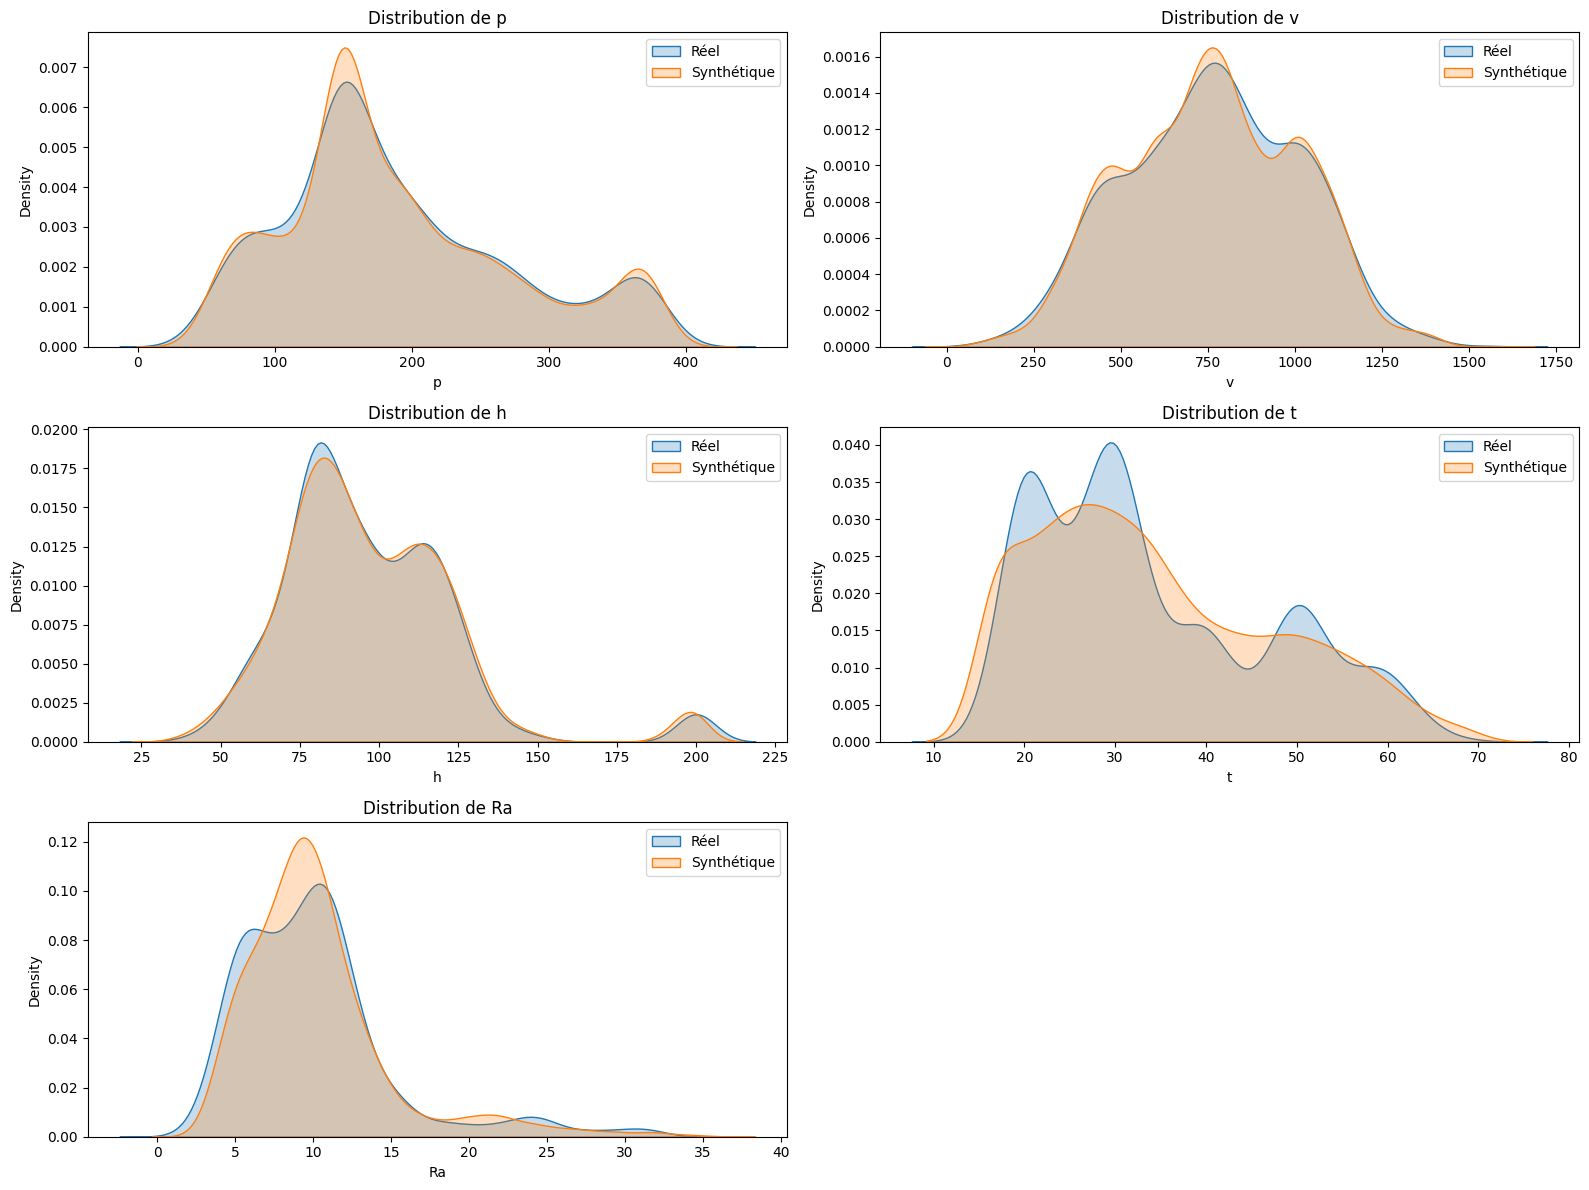

In [14]:

synthetic_final = generate_valid_synthetic_data(data_combined, scaler_x, generator, inverse_box_cox)


In [58]:
synthetic_final.shape

(5000, 5)

In [15]:

print("🔹 Données réelles :")
print(data_combined.describe())

print("\n🔹 Données synthétiques :")
print(synthetic_final.describe())


🔹 Données réelles :
                 p            v            h            t           Ra
count  1536.000000  1536.000000  1536.000000  1536.000000  1536.000000
mean    188.593354   765.215142    96.250481    34.108958    10.057232
std      83.540069   248.739651    26.900873    12.729831     5.116998
min      44.336022    71.597240    36.687026    16.385326     1.101585
25%     139.887834   590.534152    79.968547    22.954094     6.428591
50%     166.959155   769.357443    91.346862    30.002083     9.553043
75%     239.691081   962.694853   112.416213    42.663418    11.702779
max     393.167844  1555.213650   200.054491    68.824275    32.248786

🔹 Données synthétiques :
                 p            v            h            t           Ra
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000
mean    188.117741   761.909653    96.522394    34.303185    10.251946
std      83.661884   247.332198    27.167744    13.171540     4.850085
min      44.336022    71.597240

In [21]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
model = load_model("models_pvht_gmm1400/best_model.h5")
X_synth = synthetic_final[['p', 'v', 'h', 't']]
scaler_x=RobustScaler()
X_synth_scaled = scaler_x.fit_transform(X_synth)
y_pred_scaled = model.predict(X_synth_scaled)
y_pred = inverse_box_cox(y_pred_scaled)

r2 = r2_score(synthetic_final['Ra'], y_pred)
rmse = np.sqrt(mean_squared_error(synthetic_final['Ra'], y_pred))
mae = mean_absolute_error(synthetic_final['Ra'], y_pred)
print(f"R² : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE : {mae:.4f}")

157/157 [==============================] - 15s 95ms/step
R² : 0.7988
RMSE  : 2.1751
MAE : 1.4332


In [17]:

Ra_generated = synthetic_final['Ra'].values.reshape(-1, 1)
diff = np.abs(y_pred - Ra_generated)

mask = diff.flatten() < 1.0
filtered_df = synthetic_final[mask]


In [23]:
filtered_df.shape

(2640, 5)

In [22]:
model = load_model("models_pvht_gmm1400/best_model.h5")
X_synth = filtered_df[['p', 'v', 'h', 't']]
scaler_x=RobustScaler()
X_synth_scaled = scaler_x.fit_transform(X_synth)
y_pred_scaled = model.predict(X_synth_scaled)
y_pred = inverse_box_cox(y_pred_scaled)

r2 = r2_score(filtered_df['Ra'], y_pred)
rmse = np.sqrt(mean_squared_error(filtered_df['Ra'], y_pred))

mae = mean_absolute_error(filtered_df['Ra'], y_pred)
print(f"R² : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE : {mae:.4f}")


83/83 [==============================] - 9s 100ms/step
R² : 0.9653
RMSE  : 0.7494
MAE : 0.5643


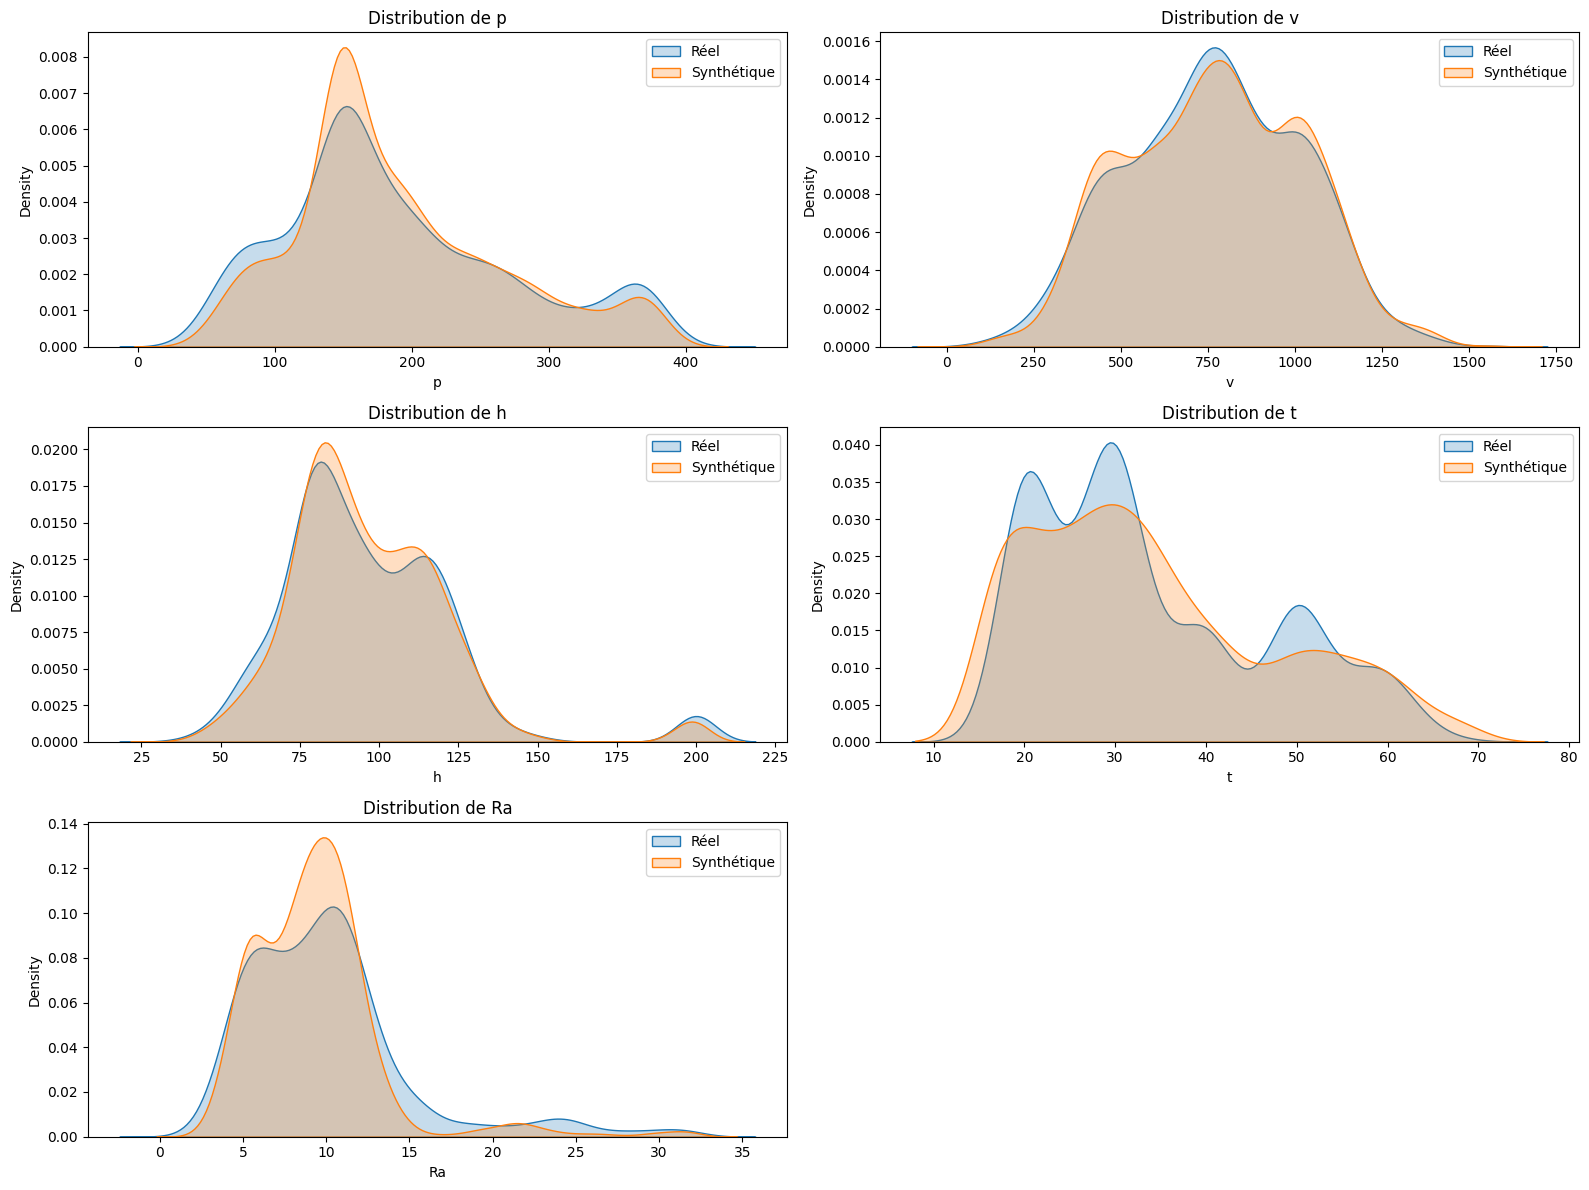

In [24]:
compare_distributions(data_combined,filtered_df)

In [31]:

from catboost import CatBoostRegressor
X_real = data_combined[['p','v','h','t']]
y_real = data_combined['Ra']





y_real_bc = box_cox_fun(y_real)


X_synth = filtered_df[['p','v','h','t']]
y_synth = filtered_df['Ra']  
y_synth_bc = box_cox_fun(y_synth)

scaler = RobustScaler()
X_synth_scaled = scaler.fit_transform(X_synth)

model = CatBoostRegressor(iterations=2000, learning_rate=0.05, depth=10, loss_function='RMSE', verbose=0)
model.fit(X_synth_scaled, y_synth_bc)

X_real_scaled = scaler.transform(X_real) 

y_pred_bc = model.predict(X_real_scaled)
y_pred = inverse_box_cox(y_pred_bc)


mse = mean_squared_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)

print(f"✅ Test sur données RÉELLES : RMSE = {np.sqrt(mse):.4f}, R² = {r2:.4f}, MAE = {mae:.4f}")


✅ Test sur données RÉELLES : RMSE = 1.9747, R² = 0.8510, MAE = 1.1659


C:\Users\hrouabah\AppData\Local\Temp\ipykernel_5928\1753019391.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_synth['Ra'] = filtered_df['Ra']


🎯 Accuracy de classification réel vs synthétique = 0.6426

🔎 Rapport de classification :
              precision    recall  f1-score   support

           0       0.52      0.03      0.07       461
           1       0.65      0.98      0.78       826

    accuracy                           0.64      1287
   macro avg       0.58      0.51      0.42      1287
weighted avg       0.60      0.64      0.52      1287



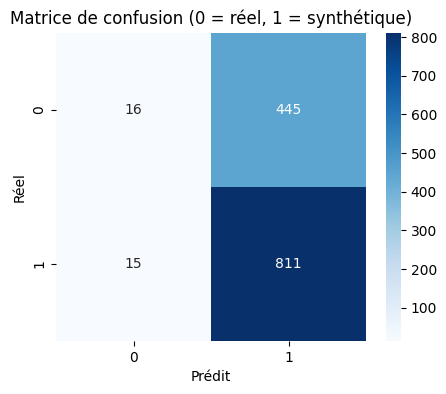

In [54]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression


X_real = data_combined[['p', 'v', 'h', 't']]
X_real['Ra'] = data_combined['Ra']
X_real['label'] = 0  

X_synth = filtered_df[['p', 'v', 'h', 't']]
X_synth['Ra'] = filtered_df['Ra']
X_synth['label'] = 1 


df_all = pd.concat([X_real, X_synth], ignore_index=True)

X = df_all.drop(columns=['label'])
y = df_all['label']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression()
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy de classification réel vs synthétique = {acc:.4f}")
print("\n🔎 Rapport de classification :")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (0 = réel, 1 = synthétique)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()


In [30]:
filtered_df.to_csv('synthetic_data_gans_filtre.csv', index=False)
